# Delivery Operations Analytics
## Identifying SLA Violations, Courier Inefficiencies & Optimization Opportunities

---

**Dataset:** `delivery_five_cities.csv` — last-mile delivery data across three Chinese cities (Shanghai, Hangzhou, Chongqing).  
**Scope:** Courier-level delivery records including timestamps, coordinates, and order metadata.  
**Goal:** Diagnose operational inefficiencies, quantify economic losses from delays, and model the impact of targeted optimization.

---

## 1. Setup — Libraries & Global Constants

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from matplotlib.patches import FancyBboxPatch, Polygon
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# Thresholds & rates
PROBLEM_THRESHOLD    = 180    # min — SLA breach threshold
RISK_THRESHOLD       = 120    # min — early-warning zone
CRITICAL_THRESHOLD   = 240    # min — critical delay
COURIER_HOUR_RATE_USD = 2.5   # USD per courier-hour
OPTIMIZATION_RATE    = 0.15   # 15% delivery-time reduction scenario
OPTIMIZATION_FACTOR  = 1 - OPTIMIZATION_RATE

# Visual theme
DARK_BG = "#04101d"
sns.set_theme(style="whitegrid")

## 2. Data Loading & Preparation

Raw delivery records are loaded, deduplicated, and enriched with derived fields needed throughout the analysis.

In [2]:
df = pd.read_csv("delivery_five_cities.csv")
df = df.drop_duplicates()

# City name translation
city_translation = {"杭州市": "Hangzhou", "上海市": "Shanghai", "重庆市": "Chongqing"}
df["city"] = df["from_city_name"].map(city_translation)
df = df[df["city"].notna()].copy()

# Parse timestamps & compute delivery duration
df["receipt_datetime"] = pd.to_datetime("2024-" + df["receipt_time"], errors="coerce")
df["sign_datetime"]    = pd.to_datetime("2024-" + df["sign_time"],    errors="coerce")
df["delivery_duration_min"] = (
    df["sign_datetime"] - df["receipt_datetime"]
).dt.total_seconds() / 60

df = df[df["delivery_duration_min"].between(0, 1440)].copy()

# Normalize coordinates (stored as int × 100 000)
for prefix in ("receipt", "poi"):
    df[f"{prefix}_lng_clean"] = df[f"{prefix}_lng"] / 100_000
    df[f"{prefix}_lat_clean"] = df[f"{prefix}_lat"] / 100_000

# Derived operational fields 
df["receipt_hour"]         = df["receipt_datetime"].dt.hour
df["is_problem_delivery"]  = df["delivery_duration_min"] > PROBLEM_THRESHOLD
df["delivery_cost_usd"]    = df["delivery_duration_min"] / 60 * COURIER_HOUR_RATE_USD
df["delay_minutes"]        = np.where(
    df["delivery_duration_min"] > PROBLEM_THRESHOLD,
    df["delivery_duration_min"] - PROBLEM_THRESHOLD, 0
)
df["delay_cost_usd"]       = df["delay_minutes"] / 60 * COURIER_HOUR_RATE_USD

#  Time bucket labels 
time_bins   = [0, 60, 120, 180, 240, float("inf")]
time_labels = ["≤ 60 min", "60–120 min", "120–180 min", "180–240 min", "> 240 min"]
df["time_group"] = pd.cut(df["delivery_duration_min"], bins=time_bins,
                          labels=time_labels, right=True)

# Optimized scenario 
df_opt = df.copy()
df_opt["optimized_delivery_time"]     = df_opt["delivery_duration_min"] * OPTIMIZATION_FACTOR
df_opt["optimized_delivery_cost_usd"] = df_opt["optimized_delivery_time"] / 60 * COURIER_HOUR_RATE_USD
df_opt["optimized_delay_minutes"]     = np.where(
    df_opt["optimized_delivery_time"] > PROBLEM_THRESHOLD,
    df_opt["optimized_delivery_time"] - PROBLEM_THRESHOLD, 0
)

# Dataset overview
overview = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Unique orders", "Unique couriers", "Cities", "Memory, MB"],
    "Value":  [df.shape[0], df.shape[1], df["order_id"].nunique(),
               df["delivery_user_id"].nunique(), df["city"].nunique(),
               round(df.memory_usage(deep=True).sum() / 1024**2, 2)]
})
display(overview)

,Metric,Value
0,Rows,465384.0
1,Columns,29.0
2,Unique orders,465384.0
3,Unique couriers,1847.0
4,Cities,3.0
5,"Memory, MB",364.0


---
## 3. Business Questions & Analysis

Ten operational questions drive this project. Each section below answers one question with data, a visualization, and an actionable recommendation.

### Business Question 1 — How is delivery volume distributed across cities, and which city carries the highest operational load?

Understanding volume distribution is the starting point for resource allocation decisions.

,city,total_deliveries,mean_time_min,median_time_min,problem_share_pct
1,Hangzhou,184346,127.6,92.0,19.2
2,Shanghai,165048,96.5,74.0,10.5
0,Chongqing,115990,192.6,138.0,37.4


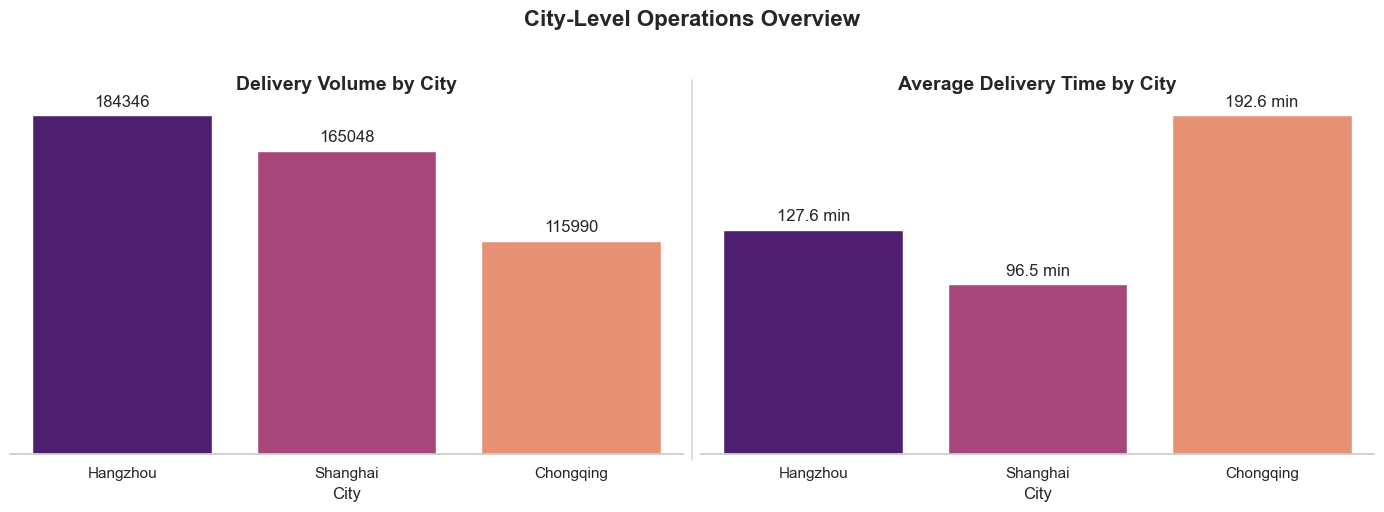

In [3]:
from matplotlib.lines import Line2D

city_summary = (
    df.groupby("city")
    .agg(
        total_deliveries=("order_id", "count"),
        mean_time_min=("delivery_duration_min", "mean"),
        median_time_min=("delivery_duration_min", "median"),
        problem_share_pct=("is_problem_delivery", "mean")
    )
    .reset_index()
)

city_summary["mean_time_min"] = city_summary["mean_time_min"].round(1)
city_summary["median_time_min"] = city_summary["median_time_min"].round(1)
city_summary["problem_share_pct"] = (
    city_summary["problem_share_pct"] * 100
).round(1)

city_summary = city_summary.sort_values(
    "total_deliveries",
    ascending=False
)

display(city_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax in axes:
    ax.set_facecolor("white")
    ax.grid(False)

    ax.set_ylabel("")
    ax.set_yticks([])
   
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)


# Delivery Volume

sns.barplot(
    data=city_summary,
    x="city",
    y="total_deliveries",
    palette="magma",
    ax=axes[0]
)

for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.0f", padding=4)

axes[0].set_title(
    "Delivery Volume by City",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("City")


# Average Delivery Time

sns.barplot(
    data=city_summary,
    x="city",
    y="mean_time_min",
    palette="magma",
    ax=axes[1]
)

for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.1f min", padding=4)

axes[1].set_title(
    "Average Delivery Time by City",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("City")


fig.add_artist(
    Line2D(
        [0.5, 0.5],
        [0.12, 0.88],
        transform=fig.transFigure,
        color="#d9d9d9",
        linewidth=1.2
    )
)

plt.suptitle(
    "City-Level Operations Overview",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

**Key Observations:** Delivery volume differs significantly across cities. Hangzhou processes the largest number of deliveries, while Chongqing handles the smallest volume. However, Chongqing has by far the longest average delivery time (192.6 minutes), indicating lower operational efficiency compared to Shanghai and Hangzhou.

**Recommendation:**  Focus optimization efforts on Chongqing, where delivery times are substantially higher than in other cities. Further investigation into courier allocation, route planning, and local operational constraints could help reduce delays and improve overall system performance.

---
### Business Question 2 — What is the distribution of delivery duration, and where does the system operate within SLA norms?

Knowing where the bulk of deliveries fall relative to the SLA threshold identifies how much of the system is already at risk.

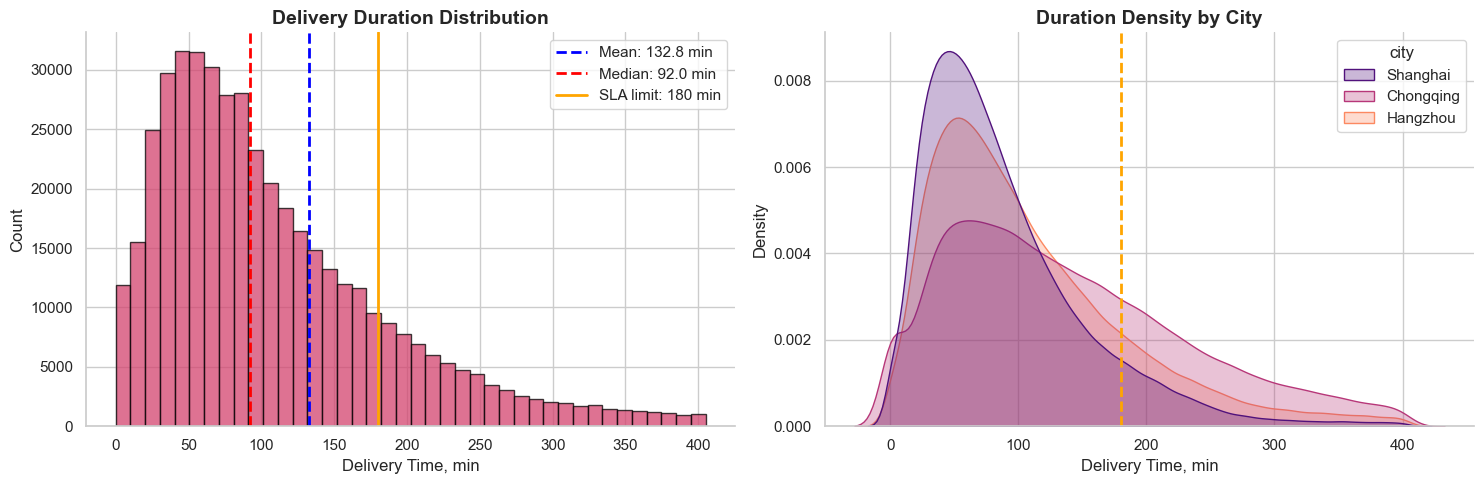

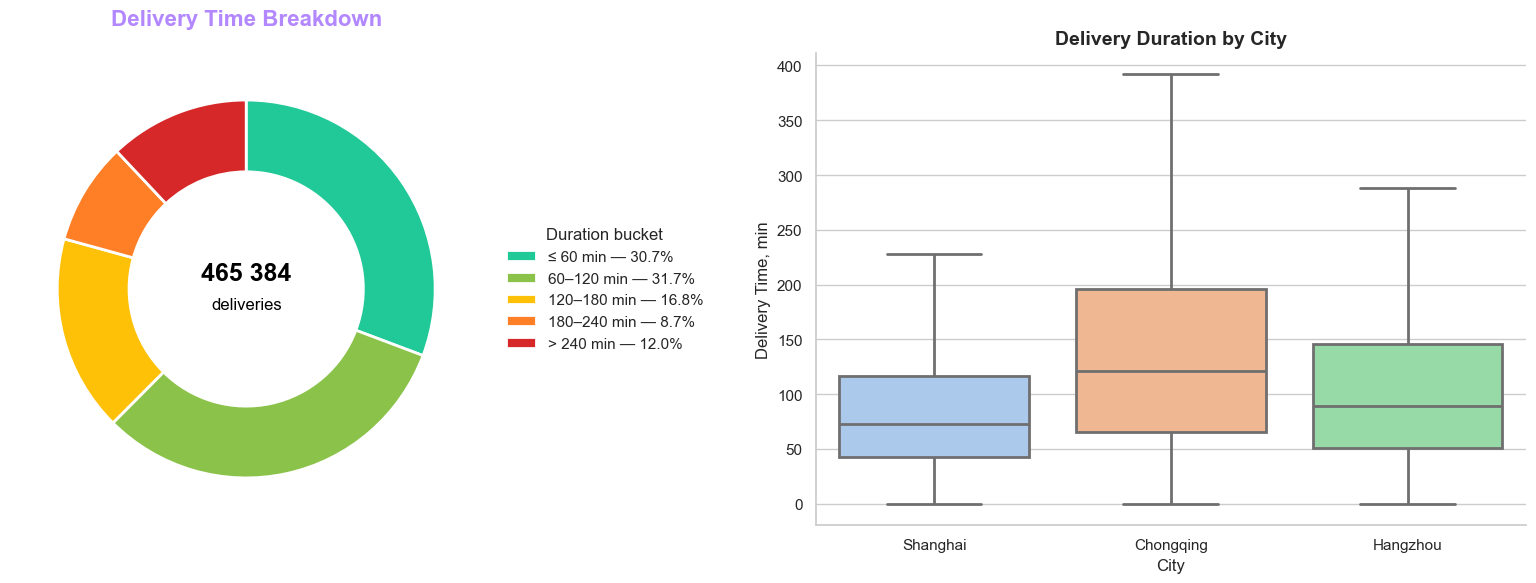

In [4]:
plot_data = df[
    df["delivery_duration_min"] <= df["delivery_duration_min"].quantile(0.95)
].copy()

mean_time = df["delivery_duration_min"].mean()
median_time = df["delivery_duration_min"].median()

# 1. Histogram + KDE

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(
    plot_data["delivery_duration_min"],
    bins=40,
    color=sns.color_palette("magma")[3],
    edgecolor="black",
    alpha=0.75
)

axes[0].axvline(mean_time, color="blue", linestyle="--", lw=2, label=f"Mean: {mean_time:.1f} min")
axes[0].axvline(median_time, color="red", linestyle="--", lw=2, label=f"Median: {median_time:.1f} min")
axes[0].axvline(PROBLEM_THRESHOLD, color="orange", linestyle="-", lw=2, label=f"SLA limit: {PROBLEM_THRESHOLD} min")

axes[0].set_title("Delivery Duration Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Delivery Time, min")
axes[0].set_ylabel("Count")
axes[0].legend()
sns.despine(ax=axes[0])

# KDE by city
sns.kdeplot(
    data=plot_data,
    x="delivery_duration_min",
    hue="city",
    fill=True,
    common_norm=False,
    alpha=0.3,
    palette="magma",
    ax=axes[1]
)

axes[1].axvline(PROBLEM_THRESHOLD, color="orange", linestyle="--", lw=2, label="SLA limit")
axes[1].set_title("Duration Density by City", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Delivery Time, min")
axes[1].set_ylabel("Density")
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


# 2. Donut + Boxplot 

time_distribution = (
    df["time_group"]
    .value_counts(normalize=True)
    .reindex(time_labels)
    .mul(100)
    .round(1)
)

donut_colors = ["#20c997", "#8bc34a", "#ffc107", "#ff7f27", "#d62828"]

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    gridspec_kw={"width_ratios": [1, 1.25]},
    facecolor="white"
)

# Donut
axes[0].set_facecolor("white")

wedges, _ = axes[0].pie(
    time_distribution,
    colors=donut_colors,
    startangle=90,
    counterclock=False,
    wedgeprops={
        "width": 0.38,
        "linewidth": 2
    }
)

axes[0].text(
    0, 0.08,
    f"{len(df):,}".replace(",", " "),
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    color="black"
)

axes[0].text(
    0, -0.08,
    "deliveries",
    ha="center",
    va="center",
    fontsize=12,
    color="black"
)

axes[0].set_title(
    "Delivery Time Breakdown",
    fontsize=16,
    fontweight="bold",
    color="#b388ff",
    pad=20
)

legend_labels = [
    f"{label} — {percent:.1f}%"
    for label, percent in zip(time_labels, time_distribution)
]

axes[0].legend(
    wedges,
    legend_labels,
    title="Duration bucket",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

# Boxplot
sns.boxplot(
    data=plot_data,
    x="city",
    y="delivery_duration_min",
    palette="pastel",
    showfliers=False,
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title(
    "Delivery Duration by City",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("City")
axes[1].set_ylabel("Delivery Time, min")

sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

**Key Observations:** Most deliveries are completed within 120 minutes, but the distribution has a long tail of delayed orders extending well beyond the 180-minute SLA threshold. A particularly important segment is the 120–180 minute range, which contains 77,624 deliveries (16.7% of total volume). These deliveries are close to the SLA limit and represent the largest opportunity for operational improvement.

**Recommendation:**  Monitor deliveries entering the 120–180 minute range and treat them as a priority risk group. Early intervention through route adjustments or courier reassignment can help prevent SLA violations before they occur.

---
### Business Question 3 — Which time-of-day windows produce the highest SLA violation rates?

Not all hours are equal. Identifying peak-risk windows lets operations pre-position resources before problems occur.

In [5]:
time_window_check = (
    df.assign(
        time_window=pd.cut(
            df["receipt_hour"],
            bins=[0, 6, 12, 18, 24],
            labels=["Ніч (00–06)", "Ранок (06–12)", "День (12–18)", "Вечір (18–24)"],
            right=False
        )
    )
    .groupby("time_window")
    .agg(
        orders=("order_id", "count"),
        sla_breach=("is_problem_delivery", "sum"),
        avg_time=("delivery_duration_min", "mean")
    )
)

time_window_check["breach_pct"] = (
    time_window_check["sla_breach"]
    / time_window_check["orders"]
    * 100
).round(1)

time_window_check["avg_time"] = (
    time_window_check["avg_time"]
).round(1)

display(time_window_check)

,orders,sla_breach,avg_time,breach_pct
time_window,,,,
Ніч (00–06),0,0,NaN,NaN
Ранок (06–12),267384,75105,159.0,28.1
День (12–18),193031,20786,98.3,10.8
Вечір (18–24),4969,152,58.8,3.1


,time_slot,total_orders,problem_orders,avg_delivery_time,sla_violation_rate
1,Morning (06–12),267384.0,75105.0,148.9,28.1
2,Day (12–18),193031.0,20786.0,96.3,10.8
3,Evening (18–24),4969.0,152.0,42.2,3.1


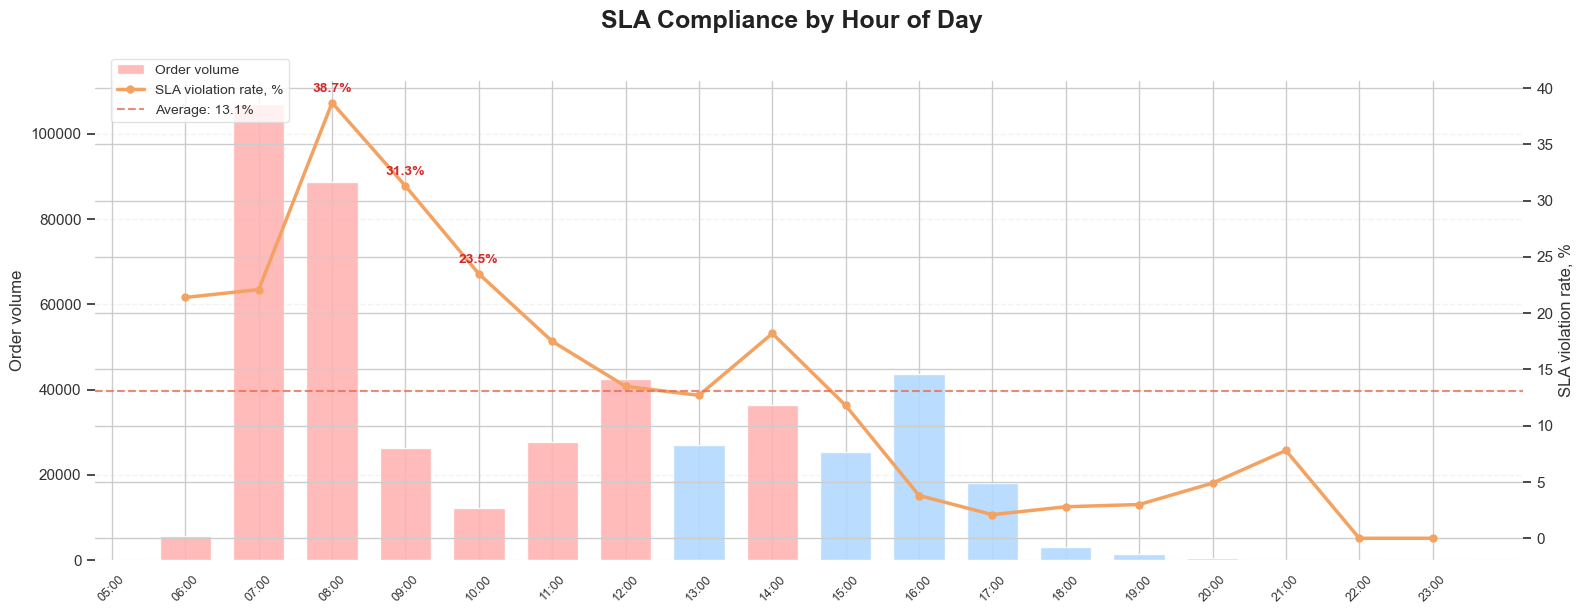

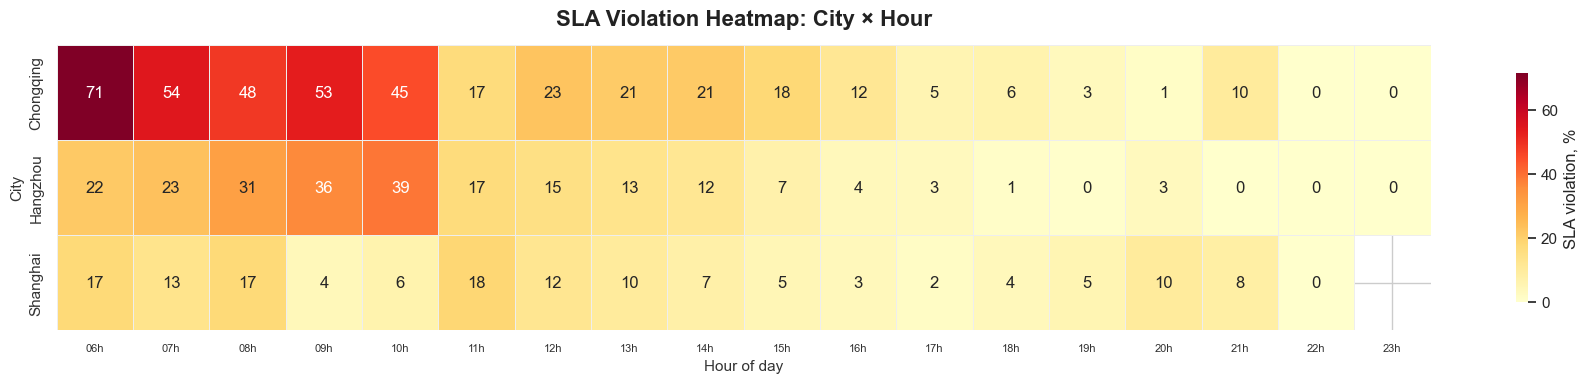

In [6]:
sla_by_hour = (
    df.groupby("receipt_hour")
    .agg(
        total_orders=("order_id", "count"),
        problem_orders=("is_problem_delivery", "sum"),
        avg_delivery_time=("delivery_duration_min", "mean")
    )
    .reset_index()
)

sla_by_hour["sla_violation_rate"] = (
    sla_by_hour["problem_orders"] / sla_by_hour["total_orders"] * 100
).round(1)

sla_by_hour["avg_delivery_time"] = sla_by_hour["avg_delivery_time"].round(1)


def _time_slot(h):
    if 6 <= h < 12:
        return "Morning (06–12)"
    elif 12 <= h < 18:
        return "Day (12–18)"
    elif 18 <= h < 24:
        return "Evening (18–24)"
    return "Night (00–06)"


slot_order = [
    "Night (00–06)",
    "Morning (06–12)",
    "Day (12–18)",
    "Evening (18–24)"
]

sla_by_hour["time_slot"] = sla_by_hour["receipt_hour"].apply(_time_slot)

sla_by_slot = (
    sla_by_hour.groupby("time_slot")
    .agg(
        total_orders=("total_orders", "sum"),
        problem_orders=("problem_orders", "sum"),
        avg_delivery_time=("avg_delivery_time", "mean")
    )
    .reset_index()
)

sla_by_slot["sla_violation_rate"] = (
    sla_by_slot["problem_orders"] / sla_by_slot["total_orders"] * 100
).round(1)

sla_by_slot["avg_delivery_time"] = sla_by_slot["avg_delivery_time"].round(1)

sla_by_slot = (
    sla_by_slot
    .set_index("time_slot")
    .reindex(slot_order)
    .reset_index()
    .dropna(subset=["total_orders"])
)

display(sla_by_slot)


# Hourly dual-axis chart — light theme

violation_threshold = sla_by_hour["sla_violation_rate"].mean()

fig, ax1 = plt.subplots(figsize=(16, 6), facecolor="white")
ax1.set_facecolor("white")

bar_colors = [
    "#ffb3b3" if v > violation_threshold else "#b3d9ff"
    for v in sla_by_hour["sla_violation_rate"]
]

ax1.bar(
    sla_by_hour["receipt_hour"],
    sla_by_hour["total_orders"],
    color=bar_colors,
    alpha=0.9,
    width=0.7,
    label="Order volume"
)

ax1.set_ylabel("Order volume", color="#333333", fontsize=12)
ax1.tick_params(axis="y", colors="#333333")
ax1.tick_params(axis="x", colors="#333333")

ax1.set_xticks(range(24))
ax1.set_xticklabels(
    [f"{h:02d}:00" for h in range(24)],
    rotation=45,
    fontsize=9
)

ax1.grid(axis="y", linestyle="--", alpha=0.25)

for sp in ax1.spines.values():
    sp.set_visible(False)


ax2 = ax1.twinx()

ax2.plot(
    sla_by_hour["receipt_hour"],
    sla_by_hour["sla_violation_rate"],
    color="#f4a261",
    lw=2.5,
    marker="o",
    ms=5,
    label="SLA violation rate, %"
)

ax2.axhline(
    violation_threshold,
    color="#e76f51",
    linestyle="--",
    lw=1.5,
    alpha=0.8,
    label=f"Average: {violation_threshold:.1f}%"
)

ax2.set_ylabel("SLA violation rate, %", color="#333333", fontsize=12)
ax2.tick_params(axis="y", colors="#333333")

for sp in ax2.spines.values():
    sp.set_visible(False)


top3 = sla_by_hour.nlargest(3, "sla_violation_rate")

for _, row in top3.iterrows():
    ax2.annotate(
        f"{row['sla_violation_rate']:.1f}%",
        xy=(row["receipt_hour"], row["sla_violation_rate"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        color="#d62828",
        fontsize=10,
        fontweight="bold"
    )


fig.legend(
    loc="upper left",
    bbox_to_anchor=(0.07, 0.95),
    frameon=True,
    facecolor="white",
    edgecolor="#dddddd",
    labelcolor="#333333",
    fontsize=10
)

fig.suptitle(
    "SLA Compliance by Hour of Day",
    fontsize=18,
    fontweight="bold",
    color="#222222",
    y=1.02
)

plt.tight_layout()
plt.show()


# SLA heatmap: city × hour — light theme

heatmap_pivot = (
    df.groupby(["city", "receipt_hour"])["is_problem_delivery"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="violation_rate")
    .pivot(index="city", columns="receipt_hour", values="violation_rate")
)

fig, ax = plt.subplots(figsize=(18, 4), facecolor="white")
ax.set_facecolor("white")

sns.heatmap(
    heatmap_pivot,
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.4,
    linecolor="#eeeeee",
    cbar_kws={
        "label": "SLA violation, %",
        "shrink": 0.8
    }
)

ax.set_title(
    "SLA Violation Heatmap: City × Hour",
    fontsize=16,
    fontweight="bold",
    color="#222222",
    pad=14
)

ax.set_xlabel("Hour of day", color="#333333", fontsize=11)
ax.set_ylabel("City", color="#333333", fontsize=11)

ax.tick_params(colors="#333333")

ax.set_xticklabels(
    [f"{h:02d}h" for h in heatmap_pivot.columns],
    rotation=0,
    fontsize=8
)

plt.tight_layout()
plt.show()

**Key Observations:**  SLA violations are heavily concentrated in the morning hours. The highest violation rates occur between 07:00 and 10:00, peaking at 38.7% at 08:00. At the same time, these hours handle the largest share of daily order volume, indicating a clear mismatch between demand and available delivery capacity.

The heatmap shows that Chongqing consistently records the highest SLA violation rates across most morning time slots, while Shanghai maintains the lowest levels throughout the day. After 16:00, violation rates decline significantly across all cities.

**Recommendation:** Prioritize operational resources during the morning peak period (07:00–10:00), when both order volume and SLA risk are highest. Increasing courier availability, improving dispatch efficiency, and proactively monitoring high-risk orders during these hours could significantly reduce overall SLA violations. Special attention should be given to Chongqing, where morning performance has the greatest impact on system-wide results.


---
### Business Question 4 — How unevenly is the workload distributed across couriers?

Unequal workload creates burnout risk, quality degradation, and underutilised capacity — all directly affecting SLA compliance.

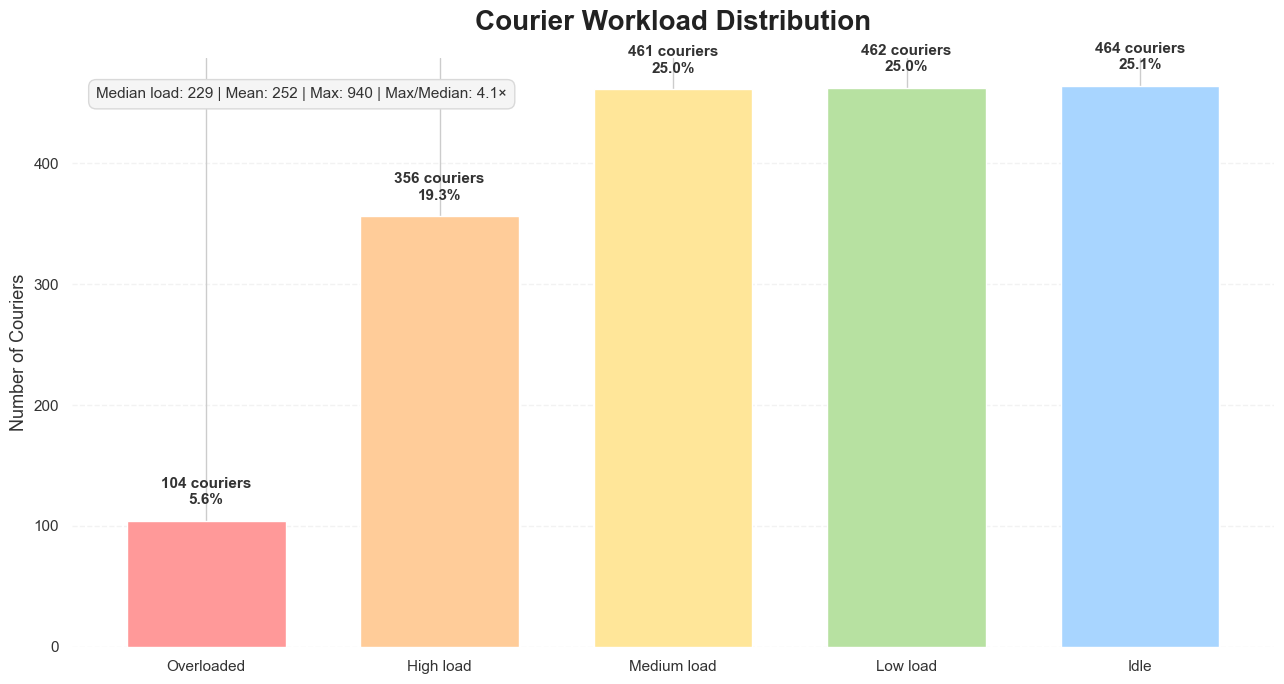

In [7]:
courier_load = (
    df.groupby("delivery_user_id")
    .agg(
        delivery_count=("order_id", "count"),
        avg_delivery_time=("delivery_duration_min", "mean")
    )
    .reset_index()
)

courier_load["avg_delivery_time"] = (
    courier_load["avg_delivery_time"].round(2)
)

median_load = courier_load["delivery_count"].median()
mean_load   = courier_load["delivery_count"].mean()
max_load    = courier_load["delivery_count"].max()

conditions = [
    courier_load["delivery_count"] > 600,
    courier_load["delivery_count"].between(383, 600),
    courier_load["delivery_count"].between(230, 382),
    courier_load["delivery_count"].between(80, 229),
    courier_load["delivery_count"] < 80,
]

load_labels = [
    "Overloaded",
    "High load",
    "Medium load",
    "Low load",
    "Idle"
]

courier_load["load_group"] = np.select(
    conditions,
    load_labels,
    default="Other"
)

load_dist = (
    courier_load["load_group"]
    .value_counts()
    .reindex(load_labels)
)

load_percent = (
    load_dist / load_dist.sum() * 100
).round(1)


# Visualization

fig, ax = plt.subplots(
    figsize=(13, 7),
    facecolor="white"
)

ax.set_facecolor("white")

bars = ax.bar(
    load_dist.index,
    load_dist.values,
    color=[
        "#ff9999",  # Overloaded
        "#ffcc99",  # High
        "#ffe699",  # Medium
        "#b7e1a1",  # Low
        "#a8d5ff"   # Idle
    ],
    width=0.68
)

ax.set_title(
    "Courier Workload Distribution",
    fontsize=20,
    fontweight="bold",
    color="#222222",
    pad=20
)

ax.set_ylabel(
    "Number of Couriers",
    fontsize=13,
    color="#333333"
)

ax.tick_params(
    axis="x",
    colors="#333333",
    labelsize=11
)

ax.tick_params(
    axis="y",
    colors="#333333"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for sp in ax.spines.values():
    sp.set_visible(False)

for bar, pct in zip(bars, load_percent):
    h = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + load_dist.max() * 0.03,
        f"{int(h)} couriers\n{pct}%",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color="#333333"
    )

ax.text(
    0.02,
    0.95,
    (
        f"Median load: {median_load:.0f} | "
        f"Mean: {mean_load:.0f} | "
        f"Max: {max_load:.0f} | "
        f"Max/Median: {max_load/median_load:.1f}×"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    color="#333333",
    bbox=dict(
        facecolor="#f5f5f5",
        edgecolor="#d9d9d9",
        boxstyle="round,pad=0.5"
    )
)

plt.tight_layout()
plt.show()

**Key Observations**

Courier workload is unevenly distributed across the network. While only 5.6% of couriers fall into the overloaded category, nearly half of the workforce operates in the low-load or idle groups. The median courier completes 229 deliveries, while the most heavily loaded courier completes 940 deliveries — more than four times the median workload. This indicates unused capacity alongside localized overload.

**Recommendation**

Improve workload balancing by redistributing orders from overloaded couriers to low-load and idle couriers. Better allocation of existing resources could reduce delivery delays, improve SLA compliance, and increase system efficiency without hiring additional couriers.

---
### Business Question 5 — Does the Pareto principle apply to courier workload — do 20% of couriers handle 80% of deliveries?

Verifying the Pareto pattern determines whether workload concentration is a structural systemic issue or a manageable imbalance.

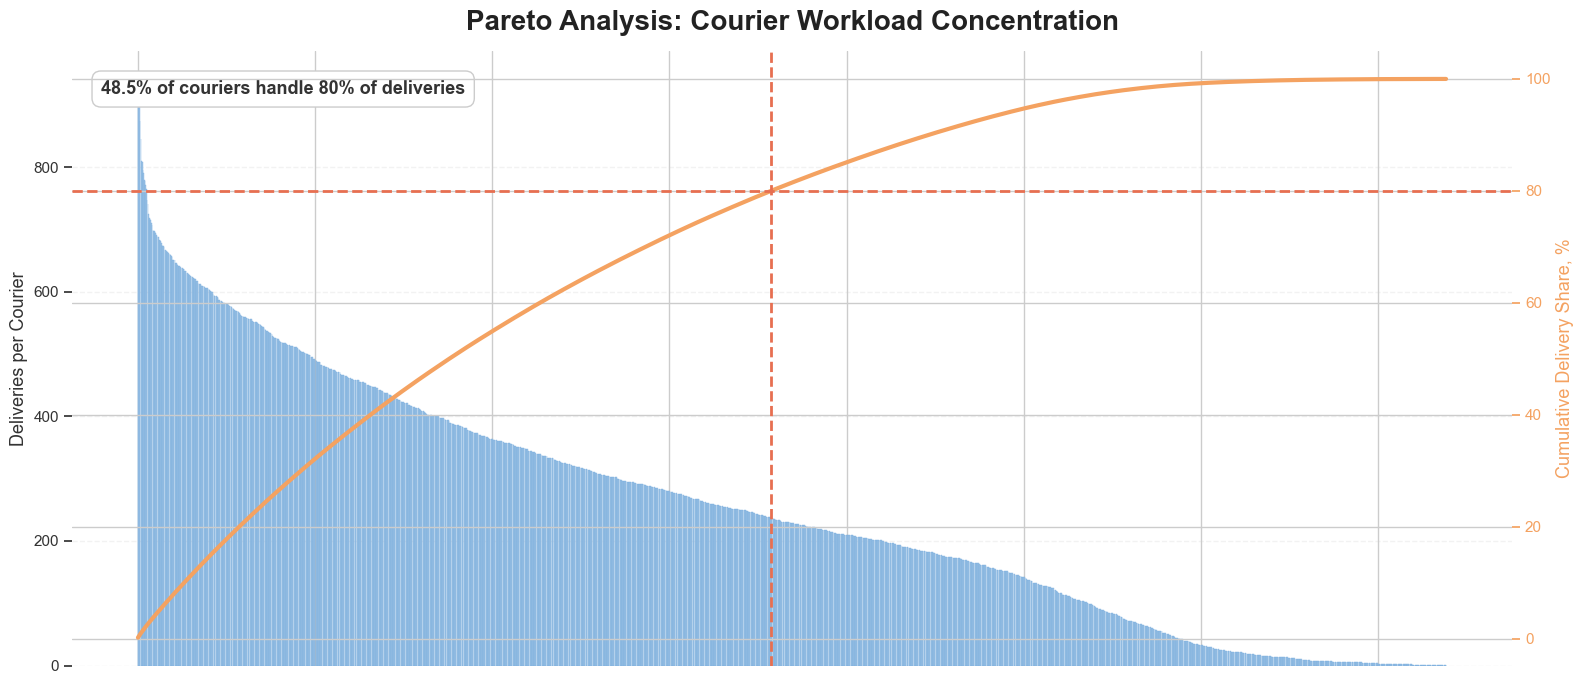

In [8]:
pareto_data = (
    courier_load
    .sort_values("delivery_count", ascending=False)
    .reset_index(drop=True)
)

pareto_data["cumulative_pct"] = (
    pareto_data["delivery_count"].cumsum()
    / pareto_data["delivery_count"].sum()
    * 100
)

x = np.arange(len(pareto_data))

fig, ax1 = plt.subplots(
    figsize=(16, 7),
    facecolor="white"
)

ax1.set_facecolor("white")

# Bars

ax1.bar(
    x,
    pareto_data["delivery_count"],
    color="#a7c7e7",
    edgecolor="#6fa8dc",
    linewidth=0.25,
    alpha=0.95
)

ax1.set_ylabel(
    "Deliveries per Courier",
    fontsize=13,
    color="#333333"
)

ax1.tick_params(
    axis="y",
    colors="#333333"
)

ax1.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)

ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for spine in ax1.spines.values():
    spine.set_visible(False)

# Pareto Line

ax2 = ax1.twinx()

ax2.plot(
    x,
    pareto_data["cumulative_pct"],
    color="#f4a261",
    linewidth=3
)

ax2.set_ylabel(
    "Cumulative Delivery Share, %",
    fontsize=13,
    color="#f4a261"
)

ax2.tick_params(
    axis="y",
    colors="#f4a261"
)

for spine in ax2.spines.values():
    spine.set_visible(False)

# 80% Threshold

pareto_80_idx = (
    pareto_data[
        pareto_data["cumulative_pct"] >= 80
    ]
    .index[0]
)

ax2.axhline(
    80,
    color="#e76f51",
    linestyle="--",
    linewidth=2
)

ax2.axvline(
    pareto_80_idx,
    color="#e76f51",
    linestyle="--",
    linewidth=2
)

# KPI Box

top_share = (pareto_80_idx + 1) / len(pareto_data) * 100

ax1.text(
    0.02,
    0.93,
    f"{top_share:.1f}% of couriers handle 80% of deliveries",
    transform=ax1.transAxes,
    fontsize=13,
    fontweight="bold",
    color="#333333",
    bbox=dict(
        facecolor="white",
        edgecolor="#cccccc",
        boxstyle="round,pad=0.5"
    )
)

# Title

plt.title(
    "Pareto Analysis: Courier Workload Concentration",
    fontsize=20,
    fontweight="bold",
    color="#222222",
    pad=15
)

plt.tight_layout()
plt.show()

**Key Observations**

Delivery workload is concentrated among a relatively small group of couriers. The Pareto analysis shows that 48.5% of couriers are responsible for 80% of all deliveries. This indicates a moderate concentration of workload, where operational performance depends disproportionately on a subset of the courier workforce.

**Recommendation**

Reduce reliance on heavily utilized couriers by distributing orders more evenly across the network. Improving workload balance can lower operational risk, reduce courier fatigue, and create additional capacity without increasing headcount.

In [9]:
# Розрахунок показників нерівномірності навантаження кур'єрів

courier_load = (
    df.groupby("delivery_user_id")
    .agg(
        delivery_count=("order_id", "count")
    )
    .reset_index()
)

total_deliveries = df["order_id"].count()
unique_couriers = df["delivery_user_id"].nunique()

mean_workload = courier_load["delivery_count"].mean()
median_workload = courier_load["delivery_count"].median()
max_workload = courier_load["delivery_count"].max()

workload_inequality_coef = max_workload / median_workload

workload_table = pd.DataFrame({
    "Показник": [
        "Загальна кількість доставок",
        "Кількість унікальних кур'єрів",
        "Середнє навантаження WL",
        "Медіанне навантаження",
        "Максимальне навантаження",
        "K_нерівн = WL_max / WL_med"
    ],
    "Значення": [
        f"{total_deliveries:,.0f}".replace(",", " "),
        f"{unique_couriers:,.0f}".replace(",", " "),
        f"{mean_workload:.0f} дост/кур'єр",
        f"{median_workload:.0f} дост/кур'єр",
        f"{max_workload:.0f} дост/кур'єр",
        f"{workload_inequality_coef:.2f}"
    ],
    "Інтерпретація": [
        "Весь аналітичний масив",
        "За усіма трьома містами",
        "Середній рівень навантаження",
        "Типовий кур'єр",
        "Найбільш завантажений кур'єр",
        f"Перевищення медіани на {(workload_inequality_coef - 1) * 100:.0f}%"
    ]
})

display(workload_table)

,Показник,Значення,Інтерпретація
0,Загальна кількість доставок,465 384,Весь аналітичний масив
1,Кількість унікальних кур'єрів,1 847,За усіма трьома містами
2,Середнє навантаження WL,252 дост/кур'єр,Середній рівень навантаження
3,Медіанне навантаження,229 дост/кур'єр,Типовий кур'єр
4,Максимальне навантаження,940 дост/кур'єр,Найбільш завантажений кур'єр
5,K_нерівн = WL_max / WL_med,4.10,Перевищення медіани на 310%


In [10]:
print("N =", total_deliveries)
print("M =", unique_couriers)
print("WL = N / M =", round(total_deliveries / unique_couriers, 2))
print("WL mean =", round(mean_workload, 2))
print("WL median =", median_workload)
print("WL max =", max_workload)
print("K нерівн =", round(workload_inequality_coef, 2))

N = 465384
M = 1847
WL = N / M = 251.97
WL mean = 251.97
WL median = 229.0
WL max = 940
K нерівн = 4.1


In [11]:
p95_workload = courier_load["delivery_count"].quantile(0.95)

print("95-й перцентиль =", p95_workload)

print(
    "K95 =",
    round(p95_workload / median_workload, 2)
)

95-й перцентиль = 609.6999999999998
K95 = 2.66


In [12]:
mean_time = df["delivery_duration_min"].mean()

q_base = 60 / mean_time

q_opt = 60 / (mean_time * 0.85)

growth_pct = (q_opt - q_base) / q_base * 100

print("Середній час =", round(mean_time, 2))
print("Q базовий =", round(q_base, 3))
print("Q оптимізований =", round(q_opt, 3))
print("Приріст =", round(growth_pct, 2), "%")

Середній час = 132.76
Q базовий = 0.452
Q оптимізований = 0.532
Приріст = 17.65 %


---
## 4. Operational Inefficiency Analysis

With volume distribution and workload patterns understood, we now shift to measuring **where the system breaks down**.

---
### Business Question 6 — What share of deliveries breach SLA, and how are risk zones distributed across cities?

Quantifying the problem scope gives management a concrete operational target to reduce.

,city,problem_share_pct
0,Chongqing,37.4
1,Hangzhou,19.2
2,Shanghai,10.5


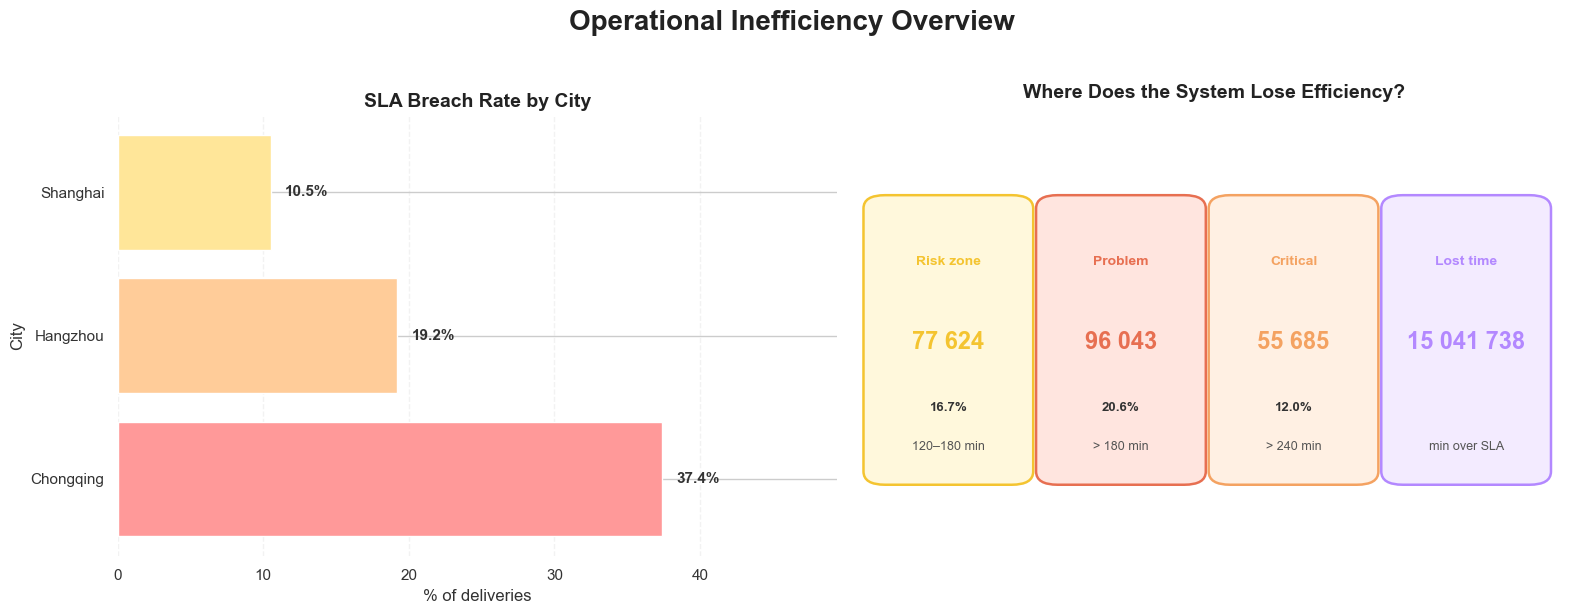

In [13]:
total_orders = len(df)

risk_orders = df[
    df["delivery_duration_min"].between(
        RISK_THRESHOLD,
        PROBLEM_THRESHOLD,
        inclusive="right"
    )
].shape[0]

problem_orders = int(df["is_problem_delivery"].sum())

critical_orders = int(
    (df["delivery_duration_min"] > CRITICAL_THRESHOLD).sum()
)

problem_by_city = (
    df.groupby("city")["is_problem_delivery"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="problem_share_pct")
    .sort_values("problem_share_pct", ascending=False)
)

display(problem_by_city)


fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    facecolor="white"
)

for ax in axes:
    ax.set_facecolor("white")


# City problem share


axes[0].barh(
    problem_by_city["city"],
    problem_by_city["problem_share_pct"],
    color=["#ff9999", "#ffcc99", "#ffe699"]
)

axes[0].set_title(
    "SLA Breach Rate by City",
    fontsize=14,
    fontweight="bold",
    color="#222222"
)

axes[0].set_xlabel("% of deliveries", color="#333333")
axes[0].set_ylabel("City", color="#333333")

axes[0].tick_params(colors="#333333")

axes[0].grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

for spine in axes[0].spines.values():
    spine.set_visible(False)

for i, v in enumerate(problem_by_city["problem_share_pct"]):
    axes[0].text(
        v + 1,
        i,
        f"{v:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#333333"
    )

axes[0].set_xlim(
    0,
    problem_by_city["problem_share_pct"].max() + 12
)


# Zone breakdown cards

axes[1].axis("off")

axes[1].set_title(
    "Where Does the System Lose Efficiency?",
    fontsize=14,
    fontweight="bold",
    color="#222222",
    pad=12
)

cards = [
    (
        "Risk zone",
        risk_orders,
        f"{risk_orders / total_orders * 100:.1f}%",
        "120–180 min",
        "#f4c430",
        "#fff8dc"
    ),
    (
        "Problem",
        problem_orders,
        f"{problem_orders / total_orders * 100:.1f}%",
        "> 180 min",
        "#e76f51",
        "#ffe5df"
    ),
    (
        "Critical",
        critical_orders,
        f"{critical_orders / total_orders * 100:.1f}%",
        "> 240 min",
        "#f4a261",
        "#fff0e3"
    ),
    (
        "Lost time",
        int(df["delay_minutes"].sum()),
        "",
        "min over SLA",
        "#b388ff",
        "#f3ebff"
    ),
]

for i, (title, val, pct, sub, color, bg_color) in enumerate(cards):
    x = 0.03 + i * 0.24

    axes[1].add_patch(
        FancyBboxPatch(
            (x, 0.18),
            0.20,
            0.62,
            boxstyle="round,pad=0.018,rounding_size=0.03",
            facecolor=bg_color,
            edgecolor=color,
            linewidth=1.8,
            alpha=1,
            transform=axes[1].transAxes
        )
    )

    axes[1].text(
        x + 0.10,
        0.66,
        title,
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=color,
        transform=axes[1].transAxes
    )

    axes[1].text(
        x + 0.10,
        0.47,
        f"{val:,.0f}".replace(",", " "),
        ha="center",
        fontsize=17,
        fontweight="bold",
        color=color,
        transform=axes[1].transAxes
    )

    if pct:
        axes[1].text(
            x + 0.10,
            0.33,
            pct,
            ha="center",
            fontsize=9.5,
            fontweight="bold",
            color="#333333",
            transform=axes[1].transAxes
        )

    axes[1].text(
        x + 0.10,
        0.24,
        sub,
        ha="center",
        fontsize=9,
        color="#555555",
        transform=axes[1].transAxes
    )


plt.suptitle(
    "Operational Inefficiency Overview",
    fontsize=20,
    fontweight="bold",
    color="#222222",
    y=1.02
)

plt.tight_layout()
plt.show()

**Key Observations**

SLA performance varies considerably across cities. Shanghai records the lowest breach rate (10.5%), while Chongqing reaches 37.4%, making it the weakest-performing location in the network. At the same time, 77,624 deliveries fall into the 120–180 minute risk zone, indicating a large group of orders that are close to violating SLA requirements. Together with 15 million minutes of accumulated delay time, these results highlight substantial operational inefficiencies and clear opportunities for improvement.

**Recommendation**

Prioritize operational improvements in Chongqing, where the potential impact on overall SLA performance is greatest. Additionally, monitor deliveries entering the 120–180 minute risk zone and introduce early intervention measures to prevent them from becoming SLA violations.

---
### Business Question 7 — What is the economic cost of delivery delays?

Translating operational failures into financial terms gives management the business case to invest in improvements.

,city,total_deliveries,total_cost_usd,delay_cost_usd,avg_delivery_cost_usd,delay_cost_pct
0,Chongqing,115990,930911.166667,337516.875000,8.03,36.3
1,Hangzhou,184346,979742.458333,208437.791667,5.31,21.3
2,Shanghai,165048,663682.875000,80784.416667,4.02,12.2


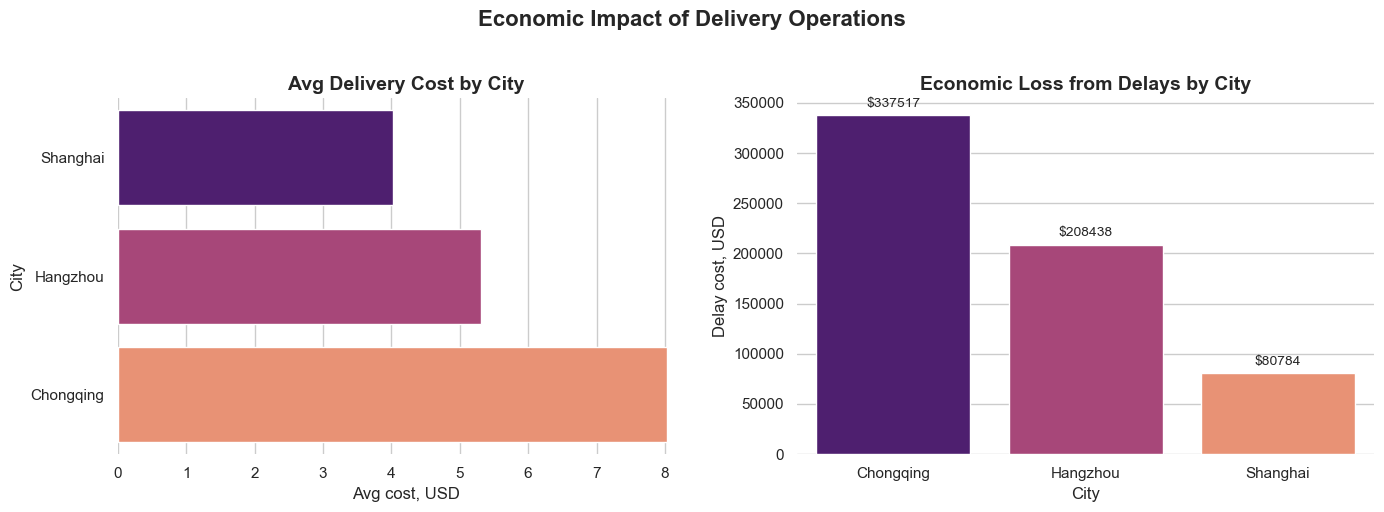


💰 Total economic loss from delays: $626,739.08
   Average delay cost as % of total delivery cost: 23.3%


In [14]:
city_costs = (
    df.groupby("city")
    .agg(total_deliveries=("order_id","count"),
         total_cost_usd=("delivery_cost_usd","sum"),
         delay_cost_usd=("delay_cost_usd","sum"))
    .reset_index()
)
city_costs["avg_delivery_cost_usd"] = (city_costs["total_cost_usd"] / city_costs["total_deliveries"]).round(2)
city_costs["delay_cost_pct"] = (city_costs["delay_cost_usd"] / city_costs["total_cost_usd"] * 100).round(1)
display(city_costs)

city_costs_s = city_costs.sort_values("avg_delivery_cost_usd", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax in axes: sns.despine(ax=ax, left=True, bottom=True)

sns.barplot(data=city_costs_s, y="city", x="avg_delivery_cost_usd",
            hue="city", palette="magma", dodge=False, ax=axes[0])
axes[0].set_title("Avg Delivery Cost by City", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Avg cost, USD"); axes[0].set_ylabel("City")
axes[0].get_legend().remove() if axes[0].get_legend() else None

delay_s = city_costs.sort_values("delay_cost_usd", ascending=False)
ax_bar = sns.barplot(data=delay_s, x="city", y="delay_cost_usd",
                     palette="magma", ax=axes[1])
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="$%.0f", padding=4, fontsize=10)
axes[1].set_title("Economic Loss from Delays by City", fontsize=14, fontweight="bold")
axes[1].set_xlabel("City"); axes[1].set_ylabel("Delay cost, USD")

plt.suptitle("Economic Impact of Delivery Operations", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

total_delay_cost = city_costs["delay_cost_usd"].sum()
print(f"\n💰 Total economic loss from delays: ${total_delay_cost:,.2f}")
print(f"   Average delay cost as % of total delivery cost: {city_costs['delay_cost_pct'].mean():.1f}%")

**Key Observations**

Delays create a significant financial burden for the delivery network. Total delay-related losses are estimated at $626,739, representing 24.3% of total delivery costs. Chongqing generates the largest share of these losses ($337,517), while also having the highest average delivery cost ($8.03 per delivery). This indicates that operational inefficiencies in Chongqing have a disproportionate impact on overall system costs.

**Recommendation**

Prioritize cost-reduction initiatives in Chongqing, where improvements are likely to generate the greatest financial return. Delay cost should be tracked as a core operational KPI alongside SLA compliance to better quantify the business impact of delivery performance.

---
## 5. Optimization Scenario

We now model a targeted 15% reduction in delivery time — achievable through route optimization, smarter dispatching, or reduced idle time — and project the operational and financial impact.

---
### Business Question 8 — What would a 15% reduction in delivery time achieve across key operational KPIs?

,KPI,Before,After,Change,Change %
0,"Avg delivery time, min",132.76,112.85,-19.91,-15.0%
1,"Median delivery time, min",92.00,78.20,-13.80,-15.0%
2,"Avg delivery cost, USD",5.53,4.70,-0.83,-15.0%
3,"Median delivery cost, USD",3.83,3.26,-0.57,-14.9%
4,Problem deliveries,96043.00,71582.00,-24461.00,-25.5%


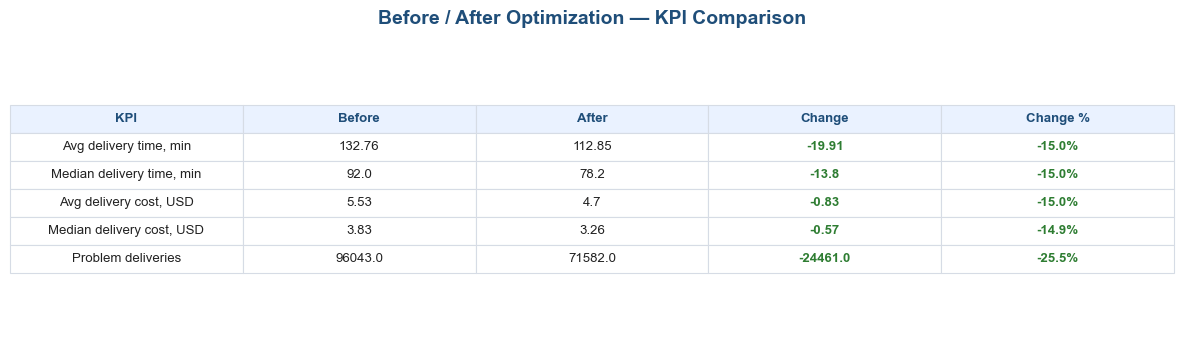

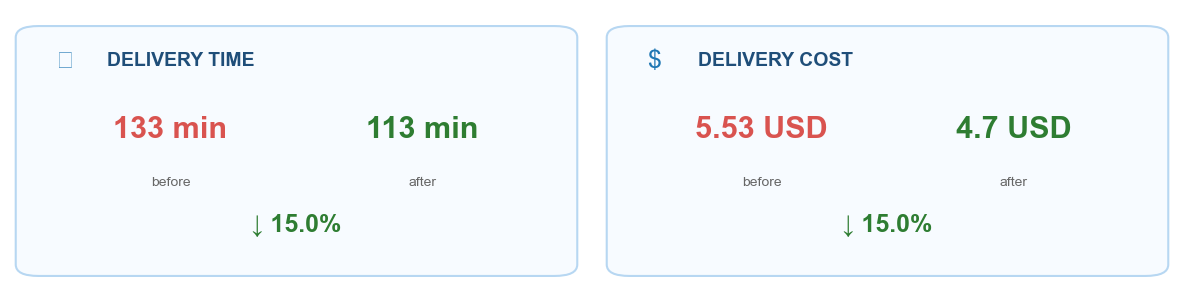

Saved delay time: 4,503,549 minutes
Saved delay time, %: 29.9%
Problem deliveries reduction: 25.5%
Optimized critical deliveries: 41585


In [15]:


# KPI calculations
total_delay_minutes = df["delay_minutes"].sum()

opt_problem_orders = int((df_opt["optimized_delivery_time"] > PROBLEM_THRESHOLD).sum())
opt_critical_orders = int((df_opt["optimized_delivery_time"] > CRITICAL_THRESHOLD).sum())

opt_total_delay = df_opt["optimized_delay_minutes"].sum()
saved_minutes = total_delay_minutes - opt_total_delay
saved_pct = saved_minutes / total_delay_minutes * 100

problem_reduction_pct = (problem_orders - opt_problem_orders) / problem_orders * 100

# KPI table
kpi_table = pd.DataFrame({
    "KPI": [
        "Avg delivery time, min",
        "Median delivery time, min",
        "Avg delivery cost, USD",
        "Median delivery cost, USD",
        "Problem deliveries"
    ],
    "Before": [
        round(df["delivery_duration_min"].mean(), 2),
        round(df["delivery_duration_min"].median(), 2),
        round(df["delivery_cost_usd"].mean(), 2),
        round(df["delivery_cost_usd"].median(), 2),
        problem_orders
    ],
    "After": [
        round(df_opt["optimized_delivery_time"].mean(), 2),
        round(df_opt["optimized_delivery_time"].median(), 2),
        round(df_opt["optimized_delivery_cost_usd"].mean(), 2),
        round(df_opt["optimized_delivery_cost_usd"].median(), 2),
        opt_problem_orders
    ],
})

kpi_table["Change"] = (kpi_table["After"] - kpi_table["Before"]).round(2)
kpi_table["Change %"] = (
    (kpi_table["Change"] / kpi_table["Before"] * 100)
    .round(1)
    .astype(str) + "%"
)

display(kpi_table)

# KPI table visualisation
fig, ax = plt.subplots(figsize=(12, 3.6), facecolor="white")
ax.axis("off")

tbl = ax.table(
    cellText=kpi_table.values,
    colLabels=kpi_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.6)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#d6dce5")
    cell.set_linewidth(0.8)

    if r == 0:
        cell.set_facecolor("#eaf2ff")
        cell.set_text_props(weight="bold", color="#1f4e79")
    else:
        cell.set_facecolor("#ffffff")
        cell.set_text_props(color="#222222")

        if c in [3, 4]:
            cell.set_text_props(color="#2e7d32", weight="bold")

ax.set_title(
    "Before / After Optimization — KPI Comparison",
    fontsize=14,
    fontweight="bold",
    color="#1f4e79",
    pad=14
)

plt.tight_layout()
plt.show()


# KPI cards
def _kpi_card(ax, title, before, after, unit, icon):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    ax.add_patch(FancyBboxPatch(
        (0.03, 0.08), 0.94, 0.84,
        boxstyle="round,pad=0.02,rounding_size=0.04",
        facecolor="#f7fbff",
        edgecolor="#b7d7f2",
        linewidth=1.5
    ))

    ax.text(0.08, 0.82, icon, fontsize=18, color="#1f77b4", va="center")
    ax.text(
        0.17, 0.82, title,
        fontsize=14,
        fontweight="bold",
        color="#1f4e79",
        va="center"
    )

    ax.text(
        0.28, 0.55, f"{before} {unit}",
        fontsize=22,
        fontweight="bold",
        color="#d9534f",
        ha="center"
    )
    ax.text(0.28, 0.38, "before", fontsize=10, color="#666666", ha="center")

    ax.text(
        0.72, 0.55, f"{after} {unit}",
        fontsize=22,
        fontweight="bold",
        color="#2e7d32",
        ha="center"
    )
    ax.text(0.72, 0.38, "after", fontsize=10, color="#666666", ha="center")

    delta = round((after - before) / before * 100, 1)

    ax.text(
        0.50, 0.22, f"↓ {abs(delta)}%",
        fontsize=18,
        fontweight="bold",
        color="#2e7d32",
        ha="center"
    )


fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), facecolor="white")

_kpi_card(
    axes[0],
    "DELIVERY TIME",
    round(df["delivery_duration_min"].mean()),
    round(df_opt["optimized_delivery_time"].mean()),
    "min",
    "◷"
)

_kpi_card(
    axes[1],
    "DELIVERY COST",
    round(df["delivery_cost_usd"].mean(), 2),
    round(df_opt["optimized_delivery_cost_usd"].mean(), 2),
    "USD",
    "$"
)

plt.tight_layout()
plt.show()

print(f"Saved delay time: {saved_minutes:,.0f} minutes")
print(f"Saved delay time, %: {saved_pct:.1f}%")
print(f"Problem deliveries reduction: {problem_reduction_pct:.1f}%")
print(f"Optimized critical deliveries: {opt_critical_orders}")

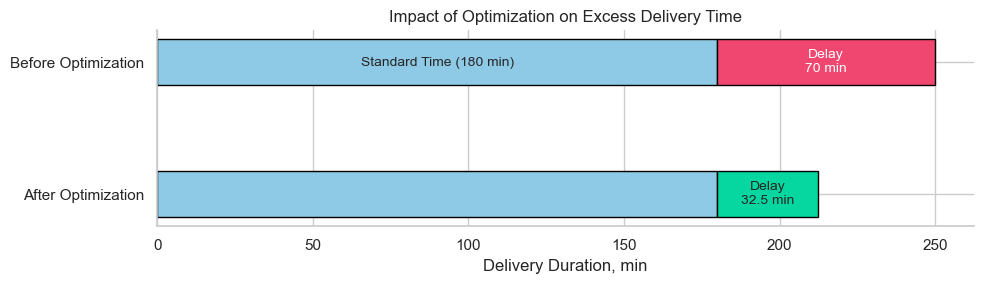

In [16]:
# Values
norm_limit = 180

before_total = 250
after_total = 212.5

before_delay = before_total - norm_limit
after_delay = after_total - norm_limit

fig, ax = plt.subplots(figsize=(10, 3))

# BEFORE
ax.barh(
    y=1,
    width=norm_limit,
    color="#8ecae6",
    edgecolor="black",
    height=0.35
)

ax.barh(
    y=1,
    width=before_delay,
    left=norm_limit,
    color="#ef476f",
    edgecolor="black",
    height=0.35
)

# AFTER
ax.barh(
    y=0,
    width=norm_limit,
    color="#8ecae6",
    edgecolor="black",
    height=0.35
)

ax.barh(
    y=0,
    width=after_delay,
    left=norm_limit,
    color="#06d6a0",
    edgecolor="black",
    height=0.35
)

# Labels
ax.text(
    90,
    1,
    "Standard Time (180 min)",
    ha="center",
    va="center",
    fontsize=10
)

ax.text(
    norm_limit + before_delay / 2,
    1,
    f"Delay\n{before_delay:.0f} min",
    ha="center",
    va="center",
    fontsize=10,
    color="white"
)

ax.text(
    norm_limit + after_delay / 2,
    0,
    f"Delay\n{after_delay:.1f} min",
    ha="center",
    va="center",
    fontsize=10
)

# Titles
ax.set_yticks([1, 0])
ax.set_yticklabels([
    "Before Optimization",
    "After Optimization"
])

ax.set_xlabel("Delivery Duration, min")
ax.set_title(
    "Impact of Optimization on Excess Delivery Time"
)

# Style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**Key Observations**

A 15% reduction in delivery time cuts excess delay by more than half (70 → 32.5 minutes). The results show that modest operational improvements can lead to substantial gains in SLA compliance and cost efficiency.

**Recommendation**

Focus on initiatives that shorten delivery times and reduce delays before they exceed the SLA threshold. The analysis suggests that small improvements can produce a disproportionately large operational benefit.

## Кількісний аналіз ефекту оптимізації транспортно-технологічного процесу

Для оцінки потенційного ефекту від удосконалення транспортно-технологічного процесу було проведено сценарне моделювання. Базовий сценарій порівнюється з оптимізованим варіантом, у якому тривалість кожної доставки зменшується на 15%.

Такий підхід дозволяє оцінити, як скорочення часу доставки вплине на ключові показники ефективності системи: середній та медіанний час доставки, варіативність процесу, кількість проблемних доставок, часові та грошові втрати, а також продуктивність кур'єрської мережі.

Для моделювання використано коефіцієнт оптимізації:

$$
T_{опт}=T_i \times 0.85
$$

де:

- $T_i$ — фактична тривалість i-ї доставки;
- $0.85$ — коефіцієнт, що відповідає скороченню часу доставки на 15%;
- $T_{опт}$ — прогнозна тривалість доставки після впровадження оптимізаційних заходів.

In [17]:
# Перевірка показників до та після оптимізації

before = df.copy()
after = df_opt.copy()

summary_optimization = pd.DataFrame({
    "Показник": [
        "Середній час доставки, хв",
        "Медіанний час доставки, хв",
        "Ст. відхилення σ, хв",
        "Коефіцієнт варіації CV",
        "Середня вартість доставки, USD",
        "Медіанна вартість, USD",
        "Кількість проблемних доставок",
        "Критично довгі доставки (>240 хв)",
        "Сумарні часові втрати, хв",
        "Грошові втрати від затримок, USD",
        "Продуктивність Q, дост/год"
    ],
    "До оптимізації": [
        before["delivery_duration_min"].mean(),
        before["delivery_duration_min"].median(),
        before["delivery_duration_min"].std(),
        before["delivery_duration_min"].std() / before["delivery_duration_min"].mean(),
        before["delivery_cost_usd"].mean(),
        before["delivery_cost_usd"].median(),
        (before["delivery_duration_min"] > PROBLEM_THRESHOLD).sum(),
        (before["delivery_duration_min"] > CRITICAL_THRESHOLD).sum(),
        before["delay_minutes"].sum(),
        before["delay_cost_usd"].sum(),
        60 / before["delivery_duration_min"].mean()
    ],
    "Після оптимізації (-15%)": [
        after["optimized_delivery_time"].mean(),
        after["optimized_delivery_time"].median(),
        after["optimized_delivery_time"].std(),
        after["optimized_delivery_time"].std() / after["optimized_delivery_time"].mean(),
        after["optimized_delivery_cost_usd"].mean(),
        after["optimized_delivery_cost_usd"].median(),
        (after["optimized_delivery_time"] > PROBLEM_THRESHOLD).sum(),
        (after["optimized_delivery_time"] > CRITICAL_THRESHOLD).sum(),
        after["optimized_delay_minutes"].sum(),
        after["optimized_delay_minutes"].sum() / 60 * COURIER_HOUR_RATE_USD,
        60 / after["optimized_delivery_time"].mean()
    ]
})

summary_optimization["Зміна, абс."] = (
    summary_optimization["Після оптимізації (-15%)"] -
    summary_optimization["До оптимізації"]
)

summary_optimization["Зміна, %"] = (
    summary_optimization["Зміна, абс."] /
    summary_optimization["До оптимізації"] *
    100
)

display(summary_optimization.round(2))

,Показник,До оптимізації,Після оптимізації (-15%),"Зміна, абс.","Зміна, %"
0,"Середній час доставки, хв",132.76,112.85,-19.91,-15.00
1,"Медіанний час доставки, хв",92.00,78.20,-13.80,-15.00
2,"Ст. відхилення σ, хв",141.43,120.22,-21.21,-15.00
3,Коефіцієнт варіації CV,1.07,1.07,0.00,0.00
4,"Середня вартість доставки, USD",5.53,4.70,-0.83,-15.00
5,"Медіанна вартість, USD",3.83,3.26,-0.57,-15.00
6,Кількість проблемних доставок,96043.00,71582.00,-24461.00,-25.47
7,Критично довгі доставки (>240 хв),55685.00,41585.00,-14100.00,-25.32
8,"Сумарні часові втрати, хв",15041738.00,10538189.35,-4503548.65,-29.94
9,"Грошові втрати від затримок, USD",626739.08,439091.22,-187647.86,-29.94


In [18]:
print("Проблемні доставки:")
print((df["delivery_duration_min"] > 180).sum())
print((df_opt["optimized_delivery_time"] > 180).sum())

print("\nКритично довгі:")
print((df["delivery_duration_min"] > 240).sum())
print((df_opt["optimized_delivery_time"] > 240).sum())

print("\nВтрачений час:")
print(round(df["delay_minutes"].sum()))
print(round(df_opt["optimized_delay_minutes"].sum()))

Проблемні доставки:
96043
71582

Критично довгі:
55685
41585

Втрачений час:
15041738
10538189


---
### Business Question 9 — What is the system's true throughput capacity, and how much additional volume could it handle after optimization?

The funnel view quantifies not just failure, but the untapped potential in the system.

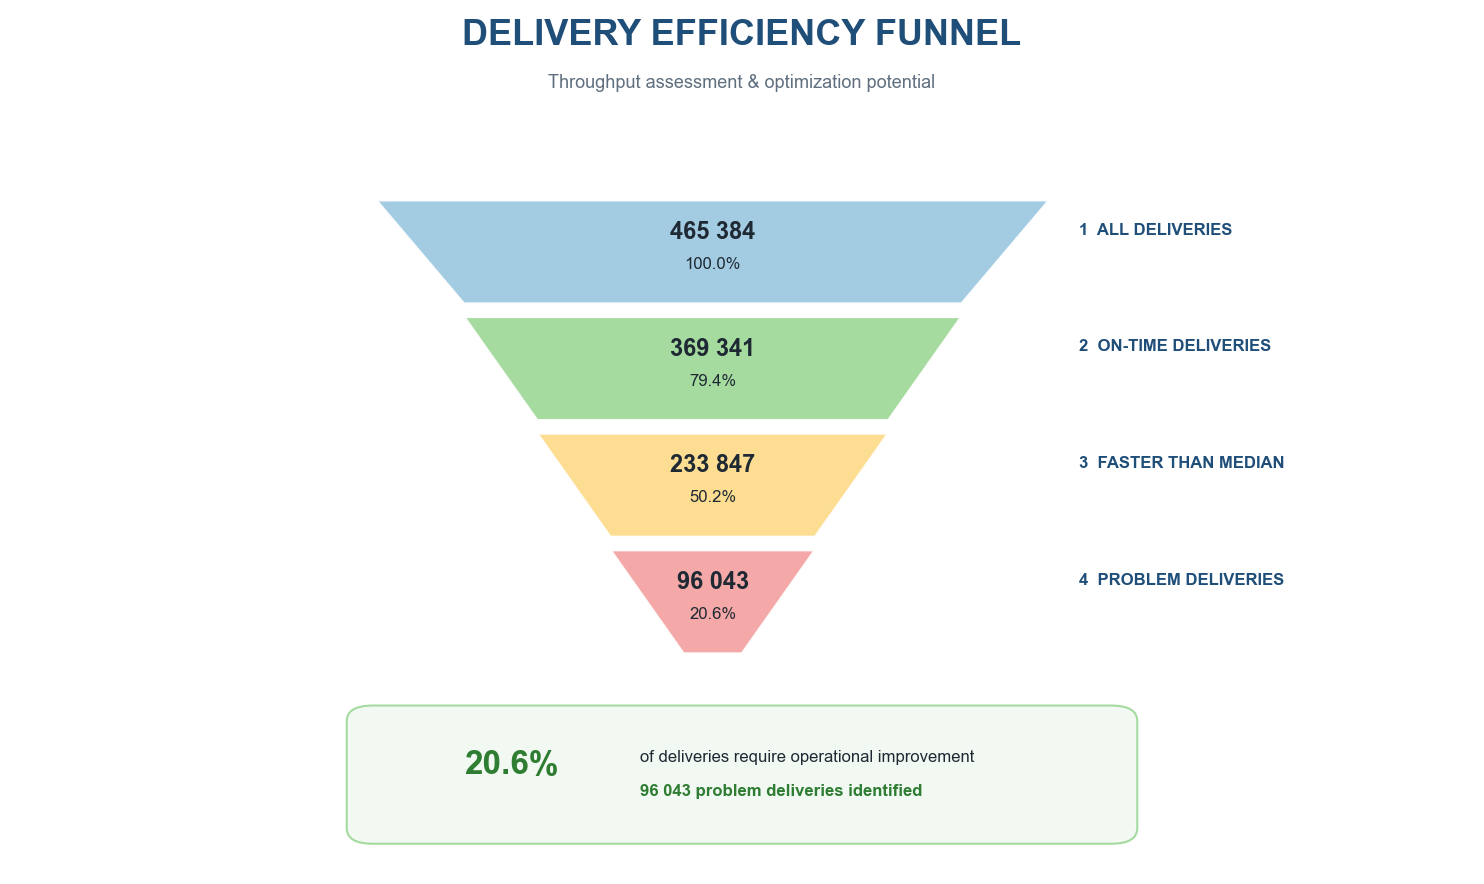

In [19]:
successful_orders = total_orders - problem_orders
fast_orders = int((df["delivery_duration_min"] <= median_time).sum())

funnel_data = [
    ("All deliveries", total_orders, 100.0),
    ("On-time deliveries", successful_orders, successful_orders / total_orders * 100),
    ("Faster than median", fast_orders, fast_orders / total_orders * 100),
    ("Problem deliveries", problem_orders, problem_orders / total_orders * 100),
]

funnel_colors = ["#9ecae1", "#a1d99b", "#fddc8c", "#f4a3a3"]
widths = [0.46, 0.34, 0.24, 0.14]

fig, ax = plt.subplots(figsize=(15, 9), facecolor="white")
ax.set_facecolor("white")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(
    0.5, 0.96,
    "DELIVERY EFFICIENCY FUNNEL",
    ha="center",
    fontsize=26,
    fontweight="bold",
    color="#1f4e79"
)

ax.text(
    0.5, 0.91,
    "Throughput assessment & optimization potential",
    ha="center",
    fontsize=13,
    color="#5f6f7f"
)

cx, h, gap, sy = 0.48, 0.12, 0.015, 0.78

for i, ((label, val, pct), color) in enumerate(zip(funnel_data, funnel_colors)):
    yt = sy - i * (h + gap)
    yb = yt - h
    wt = widths[i]
    wb = widths[i + 1] if i < len(widths) - 1 else 0.04

    pts = [
        [cx - wt / 2, yt],
        [cx + wt / 2, yt],
        [cx + wb / 2, yb],
        [cx - wb / 2, yb]
    ]

    ax.add_patch(
        Polygon(
            pts,
            facecolor=color,
            edgecolor="#ffffff",
            lw=2,
            alpha=0.95
        )
    )

    ax.text(
        cx,
        (yt + yb) / 2 + 0.015,
        f"{val:,.0f}".replace(",", " "),
        ha="center",
        fontsize=17,
        fontweight="bold",
        color="#1f2933"
    )

    ax.text(
        cx,
        (yt + yb) / 2 - 0.02,
        f"{pct:.1f}%",
        ha="center",
        fontsize=12,
        color="#1f2933"
    )

    ax.text(
        0.73,
        (yt + yb) / 2 + 0.02,
        f"{i + 1}  {label.upper()}",
        ha="left",
        fontsize=12,
        fontweight="bold",
        color="#1f4e79"
    )

capacity_growth_pct = problem_orders / total_orders * 100

ax.add_patch(
    FancyBboxPatch(
        (0.25, 0.055),
        0.50,
        0.12,
        boxstyle="round,pad=0.02,rounding_size=0.018",
        facecolor="#f2f8f2",
        edgecolor="#a1d99b",
        linewidth=1.5,
        alpha=0.95
    )
)

ax.text(
    0.31,
    0.125,
    f"{capacity_growth_pct:.1f}%",
    fontsize=24,
    fontweight="bold",
    color="#2e7d32",
    ha="left",
    va="center"
)

ax.text(
    0.43,
    0.135,
    "of deliveries require operational improvement",
    fontsize=12,
    color="#1f2933",
    ha="left",
    va="center"
)

ax.text(
    0.43,
    0.095,
    f"{problem_orders:,} problem deliveries identified".replace(",", " "),
    fontsize=12,
    fontweight="bold",
    color="#2e7d32",
    ha="left",
    va="center"
)

plt.tight_layout()
plt.show()

**Key Observations:**

Most deliveries are completed within the SLA target, with 79.4% delivered on time. However, 96,043 deliveries (20.6%) exceed the 180-minute threshold and represent the primary source of operational inefficiency. The funnel highlights the scale of improvement opportunity available through better delivery performance and SLA compliance.

**Recommendation**

Track the share of problem deliveries as a core operational KPI. Reducing this segment should be a primary objective, as even modest improvements in delivery time can significantly improve overall SLA performance and reduce delay-related costs.

---
## 6. Correlation & Regression Analysis

### Business Question 10— Which operational factors most strongly predict delivery duration?

Understanding causal drivers of delay enables targeted, evidence-based interventions rather than broad, costly changes.

,Factor,Coefficient
4,City rank,33.8566
2,Order hour,-25.1017
0,Approx distance,24.5480
1,Courier load,6.0906
3,Peak hour flag,3.3393


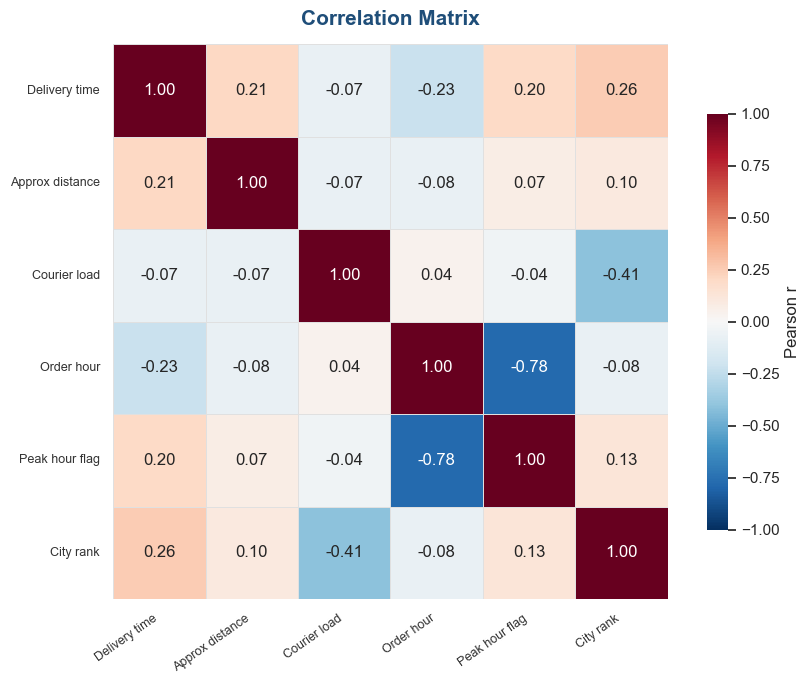

MULTIPLE LINEAR REGRESSION RESULTS
R²  = 0.1389 (13.9% variance explained)
MAE = 80.0 min
Key finding: 'City rank' is the strongest predictor (coefficient = +33.8566)


In [20]:
# Feature engineering
df["distance_approx"] = np.sqrt(
    (df["poi_lng_clean"] - df["receipt_lng_clean"])**2 +
    (df["poi_lat_clean"] - df["receipt_lat_clean"])**2
)

_courier_totals = (
    df.groupby("delivery_user_id")["order_id"]
    .count()
    .reset_index(name="courier_total_deliveries")
)

if "courier_total_deliveries" not in df.columns:
    df = df.merge(_courier_totals, on="delivery_user_id", how="left")

city_rank_map = (
    df.groupby("city")["delivery_duration_min"]
    .mean()
    .rank()
    .to_dict()
)

df["city_rank"] = df["city"].map(city_rank_map)

peak_hours = sla_by_hour.loc[
    sla_by_hour["sla_violation_rate"] > sla_by_hour["sla_violation_rate"].mean(),
    "receipt_hour"
].tolist()

df["is_peak_hour"] = df["receipt_hour"].isin(peak_hours).astype(int)

# Variables
target = "delivery_duration_min"

predictors = [
    "distance_approx",
    "courier_total_deliveries",
    "receipt_hour",
    "is_peak_hour",
    "city_rank"
]

p_labels = {
    "distance_approx": "Approx distance",
    "courier_total_deliveries": "Courier load",
    "receipt_hour": "Order hour",
    "is_peak_hour": "Peak hour flag",
    "city_rank": "City rank"
}

clean_df = df[[target] + predictors].dropna()

# Correlation matrix
corr_matrix = clean_df.rename(
    columns={**{target: "Delivery time"}, **p_labels}
).corr()

# Multiple linear regression
X = clean_df[predictors].values
y = clean_df[target].values

X_scaled = StandardScaler().fit_transform(X)

model = LinearRegression().fit(X_scaled, y)
y_pred = model.predict(X_scaled)

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

coef_df = pd.DataFrame({
    "Factor": [p_labels[p] for p in predictors],
    "Coefficient": model.coef_.round(4)
}).sort_values("Coefficient", key=abs, ascending=False)

display(coef_df)

# Correlation Matrix only
fig, ax1 = plt.subplots(
    figsize=(9, 7),
    facecolor="white"
)

ax1.set_facecolor("white")

sns.heatmap(
    corr_matrix,
    ax=ax1,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.6,
    linecolor="#e0e0e0",
    square=True,
    cbar_kws={
        "shrink": 0.75,
        "label": "Pearson r"
    }
)

ax1.set_title(
    "Correlation Matrix",
    fontsize=15,
    fontweight="bold",
    color="#1f4e79",
    pad=14
)

ax1.tick_params(
    colors="#333333",
    labelsize=9
)

for label in ax1.get_xticklabels():
    label.set_rotation(35)
    label.set_horizontalalignment("right")

for label in ax1.get_yticklabels():
    label.set_rotation(0)

plt.tight_layout()
plt.show()

# Regression results
print("MULTIPLE LINEAR REGRESSION RESULTS")
print(f"R²  = {r2:.4f} ({r2 * 100:.1f}% variance explained)")
print(f"MAE = {mae:.1f} min")

top_f = coef_df.iloc[0]["Factor"]
top_b = coef_df.iloc[0]["Coefficient"]

print(
    f"Key finding: '{top_f}' is the strongest predictor "
    f"(coefficient = {top_b:+.4f})"
)

**Key Observations:**

City-specific factors have the strongest relationship with delivery duration (r = 0.26), followed by approximate delivery distance (r = 0.21) and peak-hour conditions (r = 0.20). The regression model explains 13.9% of delivery time variability (R² = 0.139), indicating that important drivers of delays are not captured in the current dataset. This suggests that factors such as traffic conditions, parcel characteristics, and destination accessibility likely play a significant role in delivery performance.

**Recommendation**

Expand the dataset with additional operational variables, including real-time traffic data, parcel size or weight, and destination type. Improving data coverage could increase predictive accuracy and support more effective delay prevention strategies.